# Embryo Presence Classifier

## Annotation Dictionary for Embryo Presence Classification
Each entry in the dictionary represents one embryo sample, and the associated list of tuples defines inclusive frame index ranges (start, end) where the embryo is absent.

In [ ]:

NO_EMBRYO_RANGES = {
    "AAL839-6"  : [(475, 558)],
    "AB91-1"    : [(376, 558)],
    "AC264-1"   : [(209, 343)],
    "ADM715-1-2": [(358, 446)],
    "AG782-8"   : [(375, 565)],
    "AH988-4"   : [(471, 551)],
    "AHS115-5"  : [(272, 293), (474, 557)],
    "AHS599-4"  : [(459, 464)],
    #"ALR493-6"  : [(470, 566)], Truncated images
    "AM33-2"    : [(287, 562)],
    "AM716-1"   : [(476, 572)],
    "AM716-7"   : [(476, 572)],
    "AMT360-1-9": [(390, 394)],
    "AS556-3"   : [(473, 560)],
    "AS662-2"   : [(275, 466)],
    "AS1015-2"  : [(297, 371)],
    "BA518-7"   : [(464, 553)],
    "BA560-1"   : [(351, 380)], # Darkens in this range
    "BA560-2"   : [(476, 574)],
    "BA782-2"   : [(1, 1), (373, 376)],
    "BA1195-9"  : [(256, 276), (377, 663)],
    "BC254-5"   : [(381, 561)],
    "BC277-9"   : [(366, 458)],
    "BC277-10"  : [(179, 264)], # Darkens in this range
    "BC518-6"   : [(419, 551)],
    "BC750-7"   : [(465, 555)],
    "BC973-4"   : [(473, 555)],
    "BE327-2"   : [(168, 283), (473, 574)],
    "BE413-3"   : [(353, 418)],
    "BE645-7"   : [(375, 559)],
    "BF924-3"   : [(471, 557)],
    "BG201-1"   : [(191, 274)],
    "BG723-5"   : [(377, 555)],
    "BH034-4"   : [(374, 564)],
    "BI224-2"   : [(357, 423)],
    #"BJ492-8"   : [(145, 147)], Truncated Images
    "BJ497-7"   : [(190, 460)],
    "BJ3371-9"  : [(275, 413)],
    "BL042-8"   : [(478, 564)],
    "BL285-1-3" : [(473, 567)],
    "BL366-6"   : [(470, 559)],
    "BL526-1"   : [(372, 656)],
    "BL526-5"   : [(1, 13), (468, 656)],
    "BM007-9"   : [(375, 560)],
    "BM076-4"   : [(466, 554)],
    "BM201-1"   : [(374, 569)],
    "BM256-1"   : [(460, 555)],
    "BM352-6"   : [(377, 567)],
    "BM414-3"   : [(350, 413)],
    "BM968-3"   : [(295, 362)],
    "BMH857-2"  : [(367, 456)],
    "BMS819-7"  : [(484, 569)],
    "BN356-3"   : [(357, 423)],
    "BO613-7"   : [(462, 564)],
    "BR953-7"   : [(468, 563)],
    "BS495-9"   : [(472, 560)],
    "BS648-7"   : [(449, 516)],
    "BS777-8"   : [(404, 755)],
    "BS836-11"  : [(453, 545)],
    "BS918-6"   : [(558, 562)],
    "BS1033-2"  : [(370, 557)],
    "BS1086-1"  : [(480, 570)],
    "BY829-3"   : [(360, 453)],
    "CA063-6"   : [(200, 276), (464, 552)],
    "CA364-7"   : [(365, 552)],
}

EXCLUDE_FROM_TRAIN = {"AM365-7"}  # blurred embryo – keep for later tests
TRAIN_EMBRYOS = sorted(NO_EMBRYO_RANGES.keys())

## Setup: Imports, Configuration, and Utilities

In [ ]:
# Standard libs
import os, math, random, warnings
from pathlib import Path
from collections import Counter

# Numerics / data
import numpy as np
import pandas as pd

# Imaging & plots
from PIL import Image
import matplotlib.pyplot as plt

# Notebook display
from IPython.display import display

# Matplotlib defaults
plt.rcParams['figure.figsize'] = (10, 10)
plt.rcParams['axes.grid'] = False
warnings.filterwarnings("ignore")

# Reproducibility
RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

# RegEx support in python
import re

def extract_index(fp):
    """
    Searches for a pattern like "RUN12345" and extracts the numeric part. 
    If the pattern isn't found, it returns None.
    Input:
        fp: A file-like object with a 'name' attribute (e.g., a Path object).
    Output:
        An integer representing the extracted index, or None if not found.
    """
    m = re.search(r"RUN(\d+)", fp.name)
    return int(m.group(1)) if m else None

### Path Configuration and Data Validation
Establishes the directory structure and validates that required data directories exist before the training pipeline proceeds.

In [ ]:
# a Path object pointing to the parent directory of the current notebook location, 
# then calls .resolve() to convert it into an absolute filesystem path.
PROJECT_ROOT = Path('..').resolve()

# Directories for images and annotations
IMG_DIR = PROJECT_ROOT / 'data' / 'embryo_dataset_bronze'
ANN_DIR = PROJECT_ROOT / 'data' / 'embryo_dataset_annotations'

# Assertions to ensure directories exist
assert IMG_DIR.exists(), f"Not found: {IMG_DIR}  <-- check your folder structure"
assert ANN_DIR.exists(), f"Not found: {ANN_DIR}  <-- check your folder structure"

# Focal planes to train on
FOCAL_PLANES = ['F0', 'F-15', 'F-30', 'F-45', 'F15', 'F30', 'F45']

print(f"Focal planes: {FOCAL_PLANES}")
print(f"Data root: {IMG_DIR}")


Focal planes: ['F0', 'F-15', 'F-30', 'F-45', 'F15', 'F30', 'F45']
Data root: /mnt/c/Users/ioann/OneDrive/Documents/Projects/thesis/data/embryo_dataset_bronze


In [ ]:
from torch.utils.data import Dataset, DataLoader
import torch, torch.nn as nn

# Dataset for embryo presence classification
class EmbryoPresenceDataset(Dataset):
    """
    Dataset for embryo presence classification
    """
    def __init__(self, img_dir, embryo_ids, focal_planes, no_embryo_ranges, transform=None):
        """
        Initializes the dataset with image directory, embryo IDs, focal planes, and ranges without embryos.
        Inputs:
            img_dir: Path to the root image directory.
            embryo_ids: List of embryo IDs to include.
            focal_planes: List of focal planes to include.
            no_embryo_ranges: Dict mapping embryo IDs to lists of (start, end) tuples indicating frame ranges without embryos.
            transform: Optional transform to apply to images.
        """
        self.samples = []   # list of (path, label, focal_plane)
        self.transform = transform
        skipped_count = 0 # count of corrupted frames skipped

        # Iterate over focal planes
        for fp in focal_planes:
            fp_dir = img_dir / fp # e.g., IMG_DIR / 'F0'
            if not fp_dir.is_dir():
                print(f"⚠️ focal plane {fp_dir} missing - skipped")
                continue
            # Iterate over embryo IDs
            for eid in embryo_ids:
                folder = fp_dir / eid # e.g., IMG_DIR / 'F0' / 'AAL839-6'
                if not folder.is_dir():
                    continue

                # collect frame paths with index
                idx2path = {extract_index(fpath): fpath
                            for fpath in folder.glob("*.jp*g")
                            if extract_index(fpath) is not None}

                # enumerate frames and filter corrupted ones at build time
                for idx, fpath in idx2path.items():
                    # try to open and verify image is readable
                    try:
                        with Image.open(fpath) as im:
                            im.convert("L")  # verify grayscale conversion works
                    except (OSError, ValueError) as e:
                        skipped_count += 1
                        continue
                    
                    # decide label based on no_embryo_ranges
                    absent = any(s <= idx <= e for (s, e) in no_embryo_ranges[eid])
                    label = 0 if absent else 1
                    self.samples.append((fpath, label, fp))

        print(f"Dataset built with {len(self.samples):,} frames across {len(focal_planes)} focal planes (skipped {skipped_count} corrupted)")

    def __len__(self): 
        """
        Returns the total number of samples in the dataset.
        :return: Integer count of samples.
        """
        return len(self.samples)

    def __getitem__(self, i):
        path, label, fp = self.samples[i]
        with Image.open(path) as im:
            im = im.convert("L")   # 1‑channel grayscale
            if self.transform: im = self.transform(im)
        return im, torch.tensor(label, dtype=torch.long)


### Transforms & Dataloader

In [ ]:
import torchvision.transforms as T
import torchvision.transforms.v2 as v2
from torch.utils.data import WeightedRandomSampler

IMG_SIZE = 224

# Base transforms: resize, convert to tensor, normalize
tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]), # normalize to [-1, 1]
])

# Train augmentations applied BEFORE ToTensor & Normalize
train_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(45),
    T.RandomAffine(degrees=0, scale=(0.8, 1.0)), # random scale
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    T.ToTensor(),
    T.Normalize([0.5], [0.5]), # normalize to [-1, 1]
])

# --- embryo-level train / val / test split --------------------
import random
random.seed(42)

all_embryos = TRAIN_EMBRYOS.copy()
random.shuffle(all_embryos)

val_frac  = 0.20          # 10% of embryos
test_frac = 0.20          # 10% of embryos

n_val  = int(len(all_embryos) * val_frac)
n_test = int(len(all_embryos) * test_frac)

val_embryos  = all_embryos[:n_val]
test_embryos = all_embryos[n_val:n_val + n_test]
train_embryos = all_embryos[n_val + n_test:]

print(f"Train embryos: {len(train_embryos)} | Val embryos: {len(val_embryos)} | Test embryos: {len(test_embryos)}")

# Build three **separate** datasets so no embryo appears in two splits
train_ds = EmbryoPresenceDataset(IMG_DIR, train_embryos, FOCAL_PLANES, NO_EMBRYO_RANGES, transform=train_tfm)
val_ds   = EmbryoPresenceDataset(IMG_DIR, val_embryos,   FOCAL_PLANES, NO_EMBRYO_RANGES, transform=tfm)
test_ds  = EmbryoPresenceDataset(IMG_DIR, test_embryos,  FOCAL_PLANES, NO_EMBRYO_RANGES, transform=tfm)

# Class weights for imbalance: weight inversely by class frequency
train_labels = [lbl for _, lbl, _ in train_ds.samples]
class_counts = np.bincount(train_labels)
class_weights = 1.0 / (class_counts + 1e-6)  # avoid division by zero
class_weights = class_weights / class_weights.sum() * len(class_weights)  # normalize
sample_weights = np.array([class_weights[lbl] for lbl in train_labels])

weighted_sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(train_ds), replacement=True)

BATCH_SIZE = 64
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=weighted_sampler, num_workers=8, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=8, pin_memory=True)

print(f"Class distribution in train set: {dict(zip(['NO_EMBRYO', 'EMBRYO'], class_counts))}")
print(f"Class weights applied: {dict(zip(['NO_EMBRYO', 'EMBRYO'], class_weights))}")
# --------------------------------------------------------------------------


Train embryos: 39 | Val embryos: 12 | Test embryos: 12
Dataset built with 140,174 frames across 7 focal planes (skipped 3249 corrupted)
Dataset built with 140,174 frames across 7 focal planes (skipped 3249 corrupted)
Dataset built with 42,738 frames across 7 focal planes (skipped 3245 corrupted)
Dataset built with 42,738 frames across 7 focal planes (skipped 3245 corrupted)
Dataset built with 43,386 frames across 7 focal planes (skipped 0 corrupted)
Class distribution in train set: {'NO_EMBRYO': np.int64(32388), 'EMBRYO': np.int64(107786)}
Class weights applied: {'NO_EMBRYO': np.float64(1.5378886241308958), 'EMBRYO': np.float64(0.46211137586910395)}
Dataset built with 43,386 frames across 7 focal planes (skipped 0 corrupted)
Class distribution in train set: {'NO_EMBRYO': np.int64(32388), 'EMBRYO': np.int64(107786)}
Class weights applied: {'NO_EMBRYO': np.float64(1.5378886241308958), 'EMBRYO': np.float64(0.46211137586910395)}


### Model Definition

In [ ]:
import torchvision.models as models

device = "cuda" if torch.cuda.is_available() else "cpu"

# Build model: ResNet18 adapted for 1-channel input and 2 output classes
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Adapt the first convolutional layer to accept 1-channel input instead of 3
model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

# Modify the final fully connected layer for 2 classes
model.fc = nn.Linear(model.fc.in_features, 2)  # 2 classes
model.to(device)

criterion = nn.CrossEntropyLoss()  # no weight param; using WeightedRandomSampler instead
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)


### Training Loop

In [ ]:
import copy
from tqdm.auto import tqdm

EPOCHS = 50
best_val_loss = float("inf")
patience = 10          # epochs without improvement
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(1, EPOCHS+1):
    # ---- train ----
    model.train()
    running_loss, correct = 0., 0
    for x, y in tqdm(train_dl, desc=f"Epoch {epoch}", leave=False):
        # Augmentations already applied in dataset via train_tfm; no additional augmentation needed
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        y_hat = model(x)
        loss = criterion(y_hat, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        correct += (y_hat.argmax(1) == y).sum().item()

    train_loss = running_loss / len(train_ds)
    train_acc  = correct / len(train_ds)

    # ---- validate ----
    model.eval()
    running_vloss, val_correct = 0.0, 0
    with torch.no_grad():
        for x, y in val_dl:
            x, y = x.to(device), y.to(device)
            y_hat = model(x)
            vloss = criterion(y_hat, y)
            running_vloss += vloss.item() * x.size(0)
            val_correct   += (y_hat.argmax(1) == y).sum().item()

    val_loss = running_vloss / len(val_ds)
    val_acc  = val_correct  / len(val_ds)
    # ----- early-stopping on val_loss -----
    if val_loss < best_val_loss - 1e-6: # small delta to avoid ties
        best_val_loss      = val_loss
        epochs_no_improve  = 0
        best_model_wts     = copy.deepcopy(model.state_dict())
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print(f"No val-loss improvement for {patience} epochs → stopping early.")
            break

    print(f"[{epoch}] loss {train_loss:.4f} | train_acc {train_acc:.3f} | val loss {val_loss:.4f} | val acc {val_acc:.3f}")


model.load_state_dict(best_model_wts)


Epoch 1:   0%|          | 0/2191 [00:00<?, ?it/s]

[1] loss 0.0052 | train_acc 0.998 | val loss 0.0390 | val acc 0.993


Epoch 2:   0%|          | 0/2191 [00:00<?, ?it/s]

[2] loss 0.0028 | train_acc 0.999 | val loss 0.0332 | val acc 0.993


Epoch 3:   0%|          | 0/2191 [00:00<?, ?it/s]

...

Epoch 11:   0%|          | 0/2191 [00:00<?, ?it/s]

[11] loss 0.0013 | train_acc 1.000 | val loss 0.0349 | val acc 0.994


Epoch 12:   0%|          | 0/2191 [00:00<?, ?it/s]

No val-loss improvement for 10 epochs → stopping early.


<All keys matched successfully>

### Evaluation

In [43]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds, all_true = [], []

for x, y in test_dl:
    logits = model(x.to(device))
    preds  = logits.argmax(1).cpu()
    all_preds.extend(preds.numpy())
    all_true.extend(y.numpy())

test_acc = (np.array(all_preds) == np.array(all_true)).mean()
print(f"★ Test accuracy: {test_acc:.3f}")

print("\nClassification report (EMBRYO = 1, NO_EMBRYO = 0):")
print(classification_report(all_true, all_preds, target_names=["NO_EMBRYO", "EMBRYO"], digits=3))

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a7856b023b0>
Traceback (most recent call last):
  File "/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    <function _MultiProcessingDataLoaderIter.__del__ at 0x7a7856b023b0>
Traceback (most recent call last):
  File "/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1604, in __del__
    self._shutdown_workers()
  File "/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/home/khasion/miniconda3/envs/thesis/lib/python3.10/multiprocessing/process.py", line 160, in is_alive
self._shutdown_workers()
  File "/home/khasion/miniconda3/envs/thesis/lib/python3.10/site-packages/torch/utils/data/dataloader.py", line 1587, in _shutdown_workers
    if w.is_alive():
  File "/home/khasion/min

★ Test accuracy: 0.994

Classification report (EMBRYO = 1, NO_EMBRYO = 0):
              precision    recall  f1-score   support

   NO_EMBRYO      1.000     0.970     0.985      9198
      EMBRYO      0.992     1.000     0.996     34188

    accuracy                          0.994     43386
   macro avg      0.996     0.985     0.990     43386
weighted avg      0.994     0.994     0.994     43386



### Save Model + quick demo

Model trained on all 7 focal planes: ['F0', 'F-15', 'F-30', 'F-45', 'F15', 'F30', 'F45']
Model saved to embryo_presence_models/embryo_presence_resnet18_all_focal_planes.pth


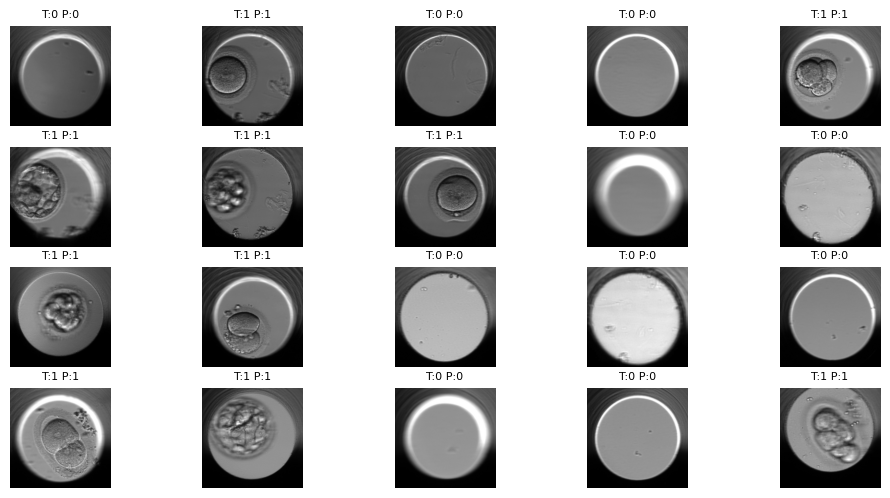

In [44]:
model.eval()
# Create output directory if needed
import os
os.makedirs("embryo_presence_models", exist_ok=True)

MODEL_PATH = "embryo_presence_models/embryo_presence_resnet18_all_focal_planes.pth"
torch.save(model, MODEL_PATH)
print(f"Model trained on all {len(FOCAL_PLANES)} focal planes: {FOCAL_PLANES}")
print(f"Model saved to {MODEL_PATH}")

# Visualise a few predictions
idx_present = [i for i, (_, lbl, _) in enumerate(test_ds.samples) if lbl == 1]
idx_absent  = [i for i, (_, lbl, _) in enumerate(test_ds.samples) if lbl == 0]

n_each = 10
sel_inds = random.sample(idx_present, n_each) + random.sample(idx_absent, n_each)
random.shuffle(sel_inds)

images = torch.stack([test_ds[i][0] for i in sel_inds])
labels = torch.tensor([test_ds[i][1] for i in sel_inds])

preds = model(images.to(device)).argmax(1).cpu()

fig, axes = plt.subplots(4, 5, figsize=(12, 6))
for ax, img, lab, pred in zip(axes.flatten(), images, labels, preds):
    ax.imshow(img.squeeze(0).numpy()*0.5 + 0.5, cmap="gray")
    ax.set_title(f"T:{lab.item()} P:{pred.item()}", fontsize=8)
    ax.axis("off")


### Grad-CAM montage: 50% Embryo, 50% No Embryo (test frames)


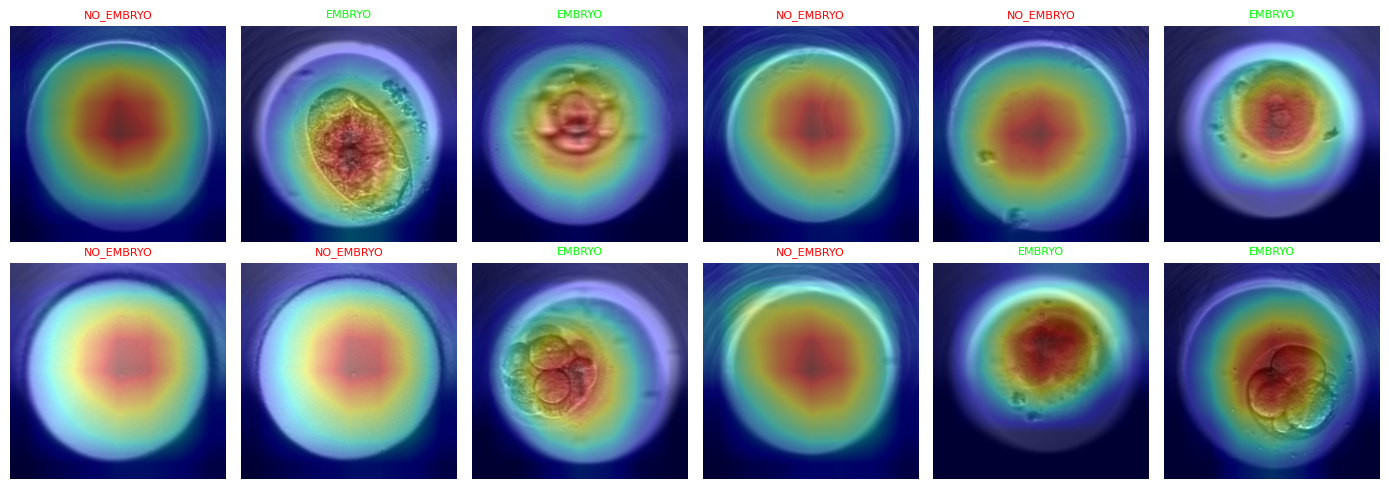

In [49]:
# --------------------------------------------------------------
# Grad-CAM montage: 50 % EMBRYO, 50 % NO_EMBRYO (test frames)
# --------------------------------------------------------------
from torchcam.methods import GradCAM
import torch.nn.functional as F

model.eval()                                  # keep weights frozen
cam_extractor = GradCAM(model, target_layer=model.layer4[-1])

# ----- 1. Balanced sampling -------------------------------------------------
random.seed(0)

idx_embryo = [i for i, (_, lbl, _) in enumerate(test_ds.samples) if lbl == 1]
idx_empty  = [i for i, (_, lbl, _) in enumerate(test_ds.samples) if lbl == 0]

n_each = 6
sel_inds = random.sample(idx_embryo, n_each) + random.sample(idx_empty, n_each)
random.shuffle(sel_inds)

# ----- 2. Compute CAMs -------------------------------------------------------
images, labels, cams = [], [], []
for idx in sel_inds:
    x, lbl = test_ds[idx]           # x: [C,H,W] tensor
    x_batch = x.unsqueeze(0).to(device)

    # Forward *with* gradients
    logits = model(x_batch)

    # CAM for the predicted class (or use lbl to see GT class)
    cls_id = logits.argmax(1).item()
    cam_small = cam_extractor(cls_id, scores=logits)[0]
    cam_small = cam_small.squeeze(0)

    # Upsample to input resolution
    cam_up = F.interpolate(cam_small.unsqueeze(0).unsqueeze(0),
                           size=(IMG_SIZE, IMG_SIZE),
                           mode='bilinear',
                           align_corners=False).squeeze()

    cam_up = (cam_up - cam_up.min()) / (cam_up.max() - cam_up.min() + 1e-6)

    images.append(x)
    labels.append(lbl)
    cams.append(cam_up.cpu())

# ----- 3. Plot grid ----------------------------------------------------------
n_cols = 6
n_rows = math.ceil(len(images) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 2.5*n_rows))

for ax, img, lbl, cam in zip(axes.flatten(), images, labels, cams):
    base = img.squeeze()*0.5 + 0.5      # un-normalise to [0,1]
    ax.imshow(base.numpy(), cmap='gray')
    ax.imshow(cam.numpy(), cmap='jet', alpha=0.4)
    ax.set_title("EMBRYO" if lbl==1 else "NO_EMBRYO", fontsize=8,
                 color='lime' if lbl==1 else 'red')
    ax.axis('off')

plt.tight_layout()
plt.show()
# --------------------------------------------------------------
